✅ Libraries Imported!
✅ Dataset loaded successfully!
Shape: (7043, 21) (rows , columns)

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic 

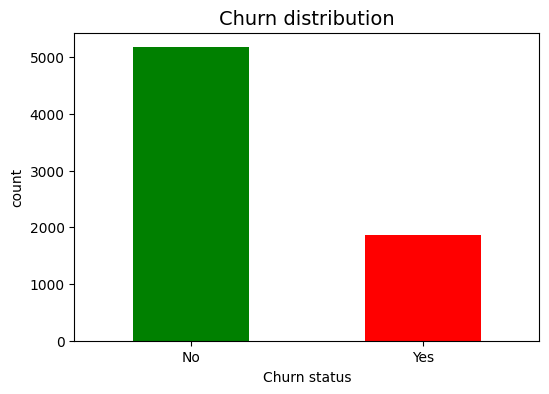

Estimated annual revenue loss: $1,452,475.24
If we reduce churn by 20% we save: 290,495.05 Annually!

--- STEP 4: DATA CLEANING & PREPARATION ---
Empty DataFrame
Columns: [Missing Count, Percentage]
Index: []
Current columns: 
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

✓ Removed 'customerID' column

Remaining columns (20 columns):
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Encode categorical variables:
Text columns found: ['gender', 'Partner', 'D

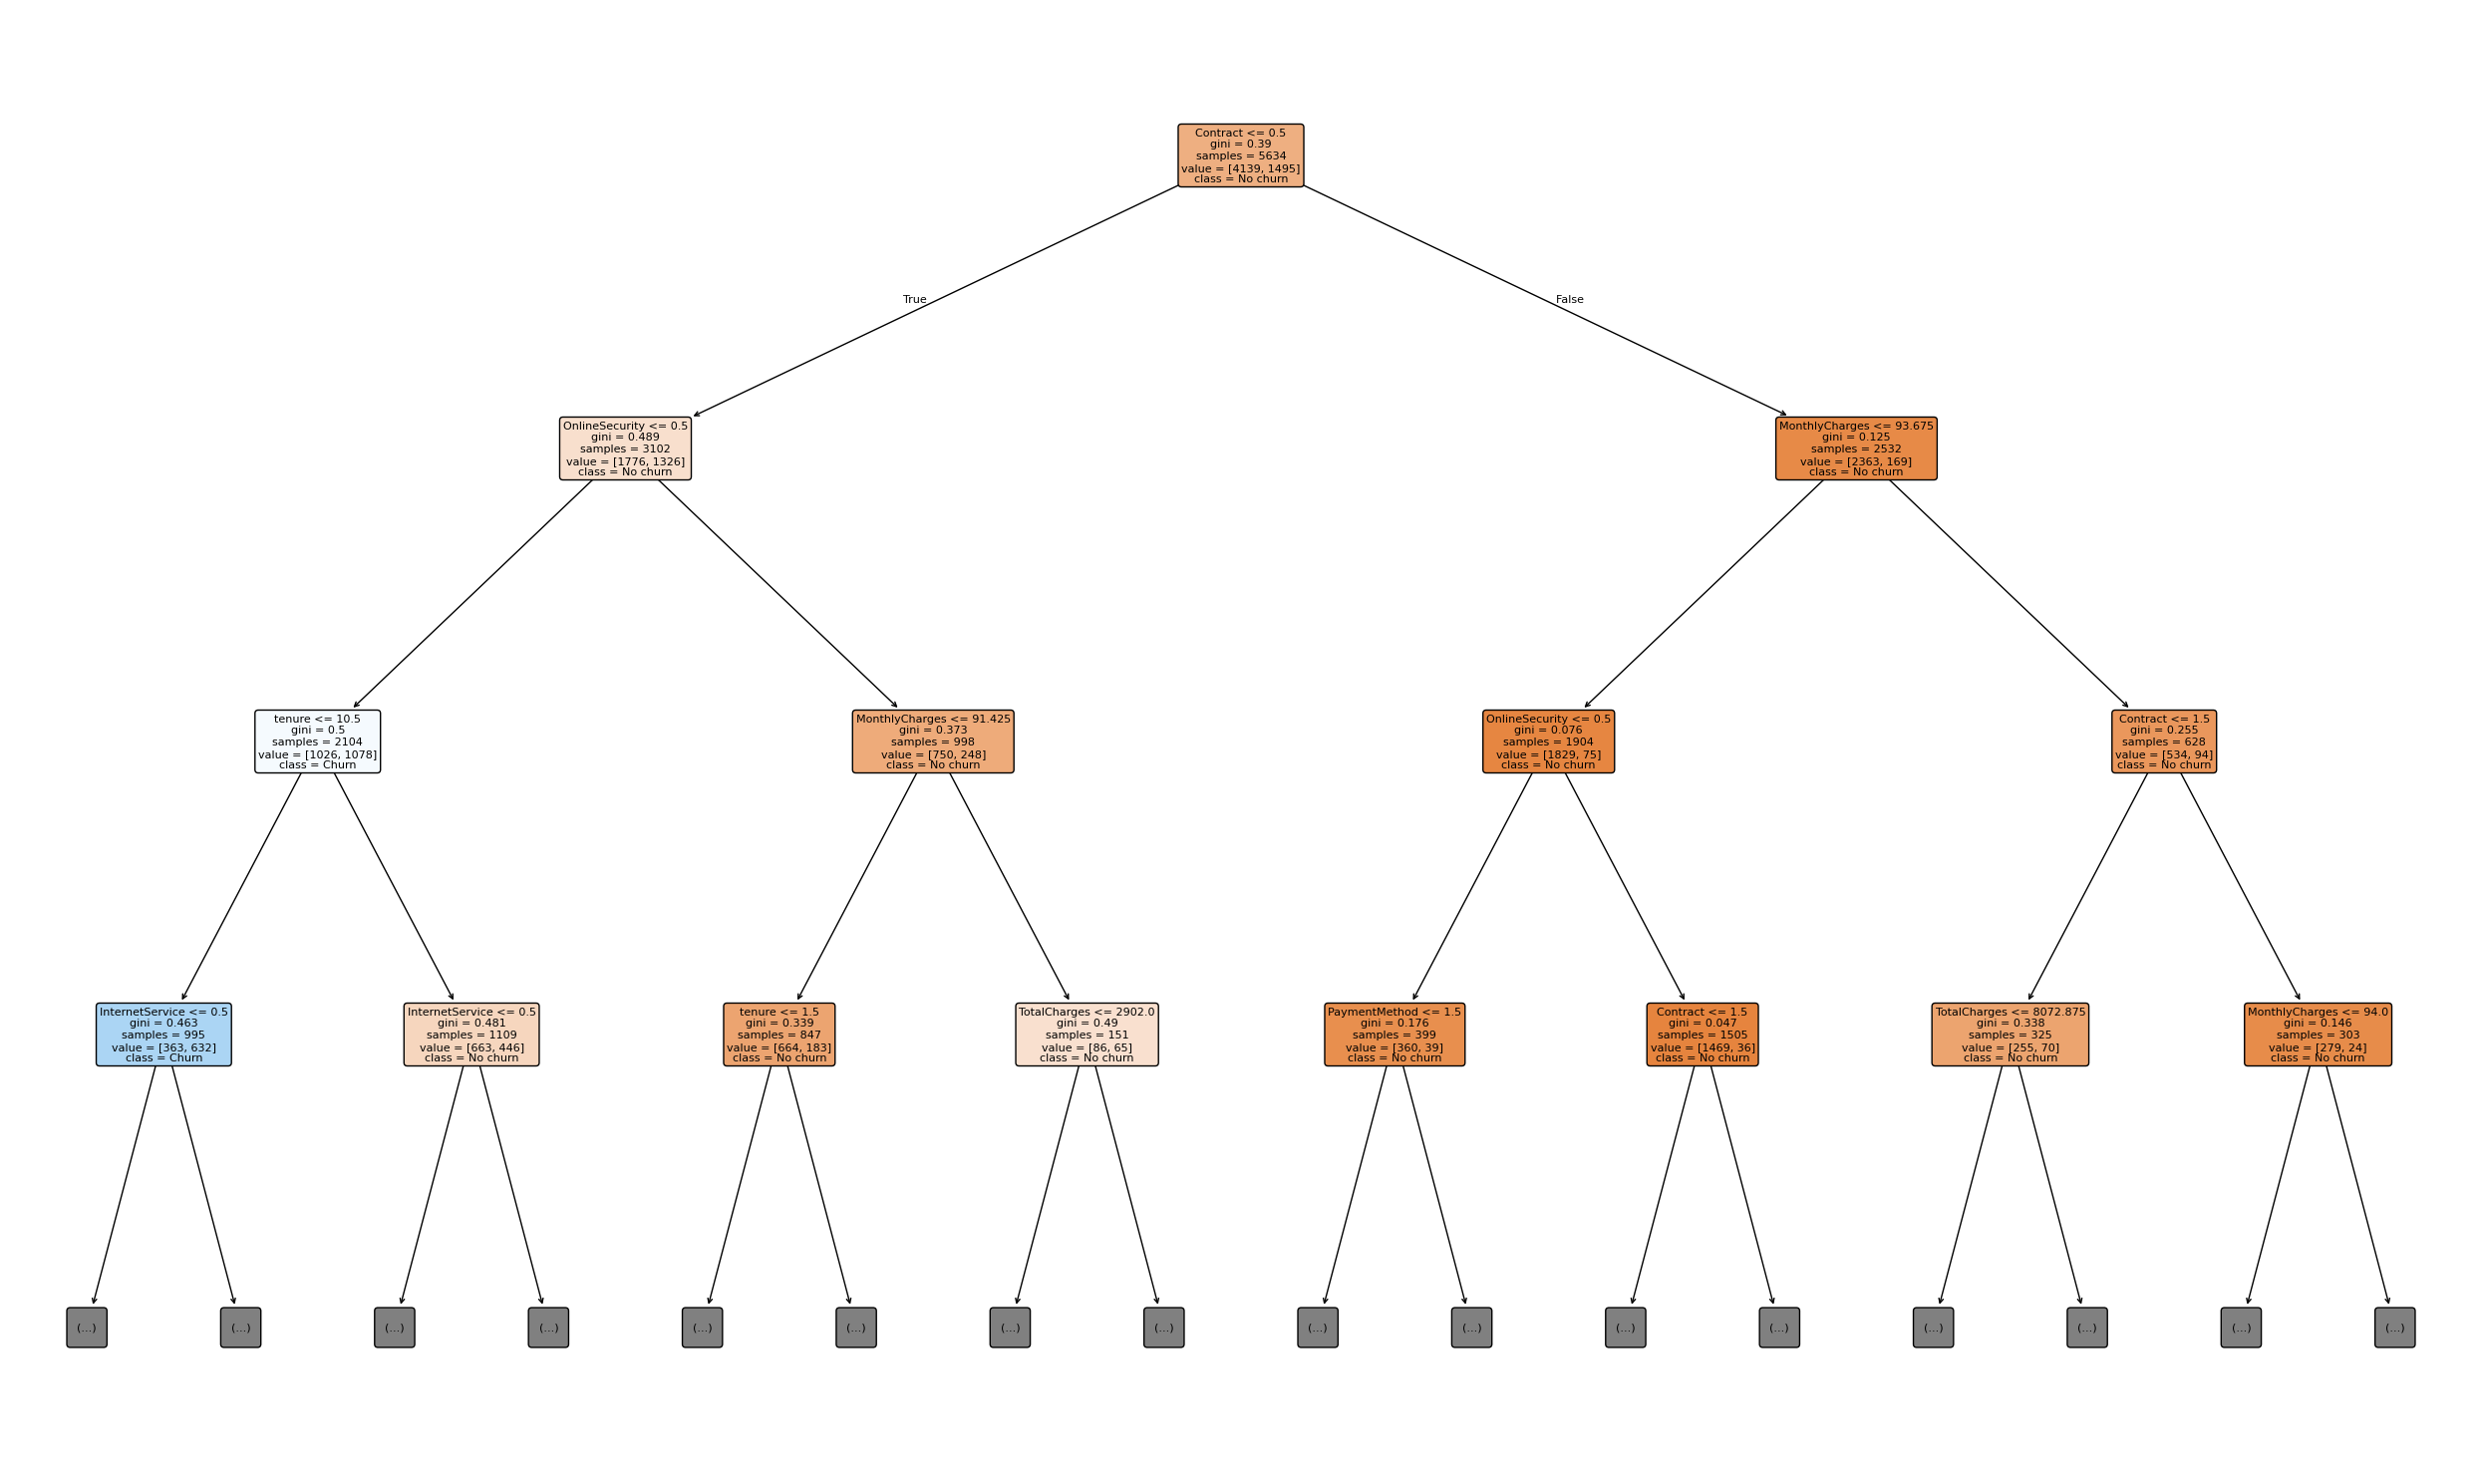


✓ Tree displayed above!

What each box shows:
  ┌─────────────────────────────┐
  │ Contract <= 0.5             │ ← Question asked
  │ gini = 0.4                  │ ← Purity score (0=perfect)
  │ samples = 1200              │ ← How many customers here
  │ value = [850, 350]          │ ← [No Churn, Churn] counts
  │ class = No Churn            │ ← Final prediction
  └─────────────────────────────┘
TOP 10 MOST IMPORTANT FEATURES FOR PREDICTING CHURN:
        Feature  Importance
       Contract    0.525341
 OnlineSecurity    0.138973
         tenure    0.099174
InternetService    0.091187
   TotalCharges    0.060525
 MonthlyCharges    0.057434
  PaymentMethod    0.018331
  SeniorCitizen    0.006759
    TechSupport    0.002142
   OnlineBackup    0.000135


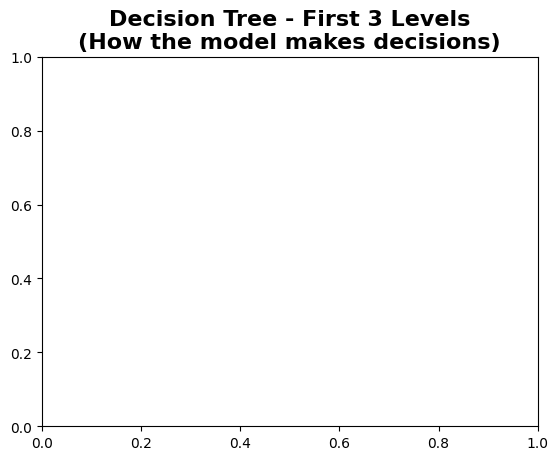

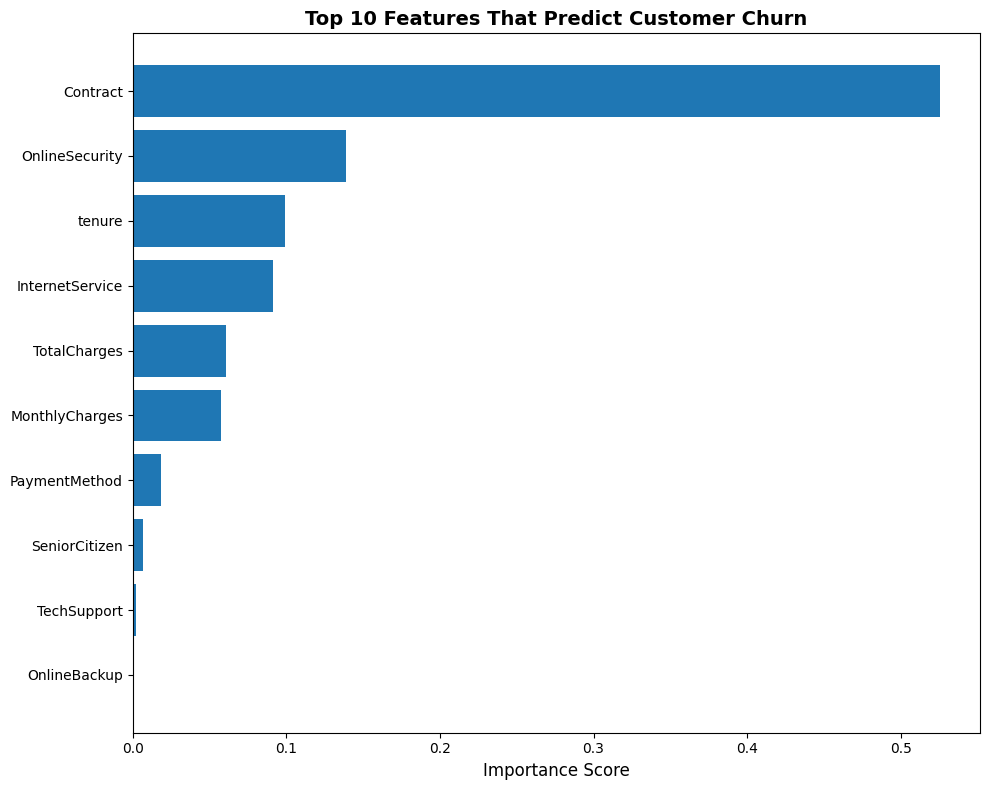


✓ Feature importance chart displayed above!
BUSINESS RULES FROM DECISION TREE (Top rules):

These are simple IF-THEN rules the tree learned:

RULE 1:
  IF Contract <= 0.50 AND OnlineSecurity <= 0.50 AND tenure <= 10.50
  THEN Predict: Churn (Churn Rate: 63.5%)
  Applies to: 1 customers

RULE 2:
  IF Contract <= 0.50 AND OnlineSecurity <= 0.50 AND tenure > 10.50
  THEN Predict: No Churn (Churn Rate: 40.2%)
  Applies to: 1 customers

RULE 3:
  IF Contract <= 0.50 AND OnlineSecurity > 0.50 AND MonthlyCharges <= 91.42
  THEN Predict: No Churn (Churn Rate: 21.6%)
  Applies to: 1 customers

RULE 4:
  IF Contract <= 0.50 AND OnlineSecurity > 0.50 AND MonthlyCharges > 91.42
  THEN Predict: No Churn (Churn Rate: 43.0%)
  Applies to: 1 customers

RULE 5:
  IF Contract > 0.50 AND MonthlyCharges <= 93.67 AND OnlineSecurity <= 0.50
  THEN Predict: No Churn (Churn Rate: 9.8%)
  Applies to: 1 customers

RULE 6:
  IF Contract > 0.50 AND MonthlyCharges <= 93.67 AND OnlineSecurity > 0.50
  THEN Predict

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All files downloaded!
📁 Check your browser's Downloads folder


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder # Import LabelEncoder
print('✅ Libraries Imported!')

#Loading dataset:
df = pd.read_csv('Telco-Customer-Churn.csv')
print('✅ Dataset loaded successfully!')
print(f'Shape: {df.shape} (rows , columns)')
print('\nFirst 5 rows:')
print(df.head())

#Checking dataset and missing values
print("-" * 50)
df.info()

print("\n" + "-" * 50)
print("Missing values check")
print("-" * 50)
print(df.isnull().sum())

print("\n" + "="*50)
print("Using df.describe():")
df.describe()

#Understanding target variable
print("="*60)
print("TARGET VARIABLE: CHURN ANALYSIS")
print("="*60)
churn_counts = (df['Churn'].value_counts())
churn_pct = (df['Churn'].value_counts(normalize = True) * 100)
print(f"Customers who churned: {churn_counts['Yes']} ({churn_pct['Yes']:.1f}%)")
print(f"Customers who stayed: {churn_counts['No']} ({churn_pct['No']:.1f}%)")
#Visualization
plt.figure(figsize=(6,4))
df['Churn'].value_counts().plot(kind = 'bar', color = ['green', 'red'])
plt.title("Churn distribution", fontsize =  14)
plt.xlabel('Churn status')
plt.ylabel("count")
plt.xticks(rotation = 0)
plt.show()

#Business impact
avg_charge = df['MonthlyCharges'].mean()
revenue_loss = churn_counts['Yes'] * avg_charge * 12
print(f"Estimated annual revenue loss: ${revenue_loss:,.2f}")
print(f"If we reduce churn by 20% we save: {revenue_loss * 0.2:,.2f} Annually!")

print("\n--- STEP 4: DATA CLEANING & PREPARATION ---")
#Missing values in all the columns
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count':missing_values,'Percentage':missing_percent})
print(missing_df[missing_df['Missing Count'] > 0])
#removing unnecessary columns
print("Current columns: ")
print(df.columns.tolist())
#Removing 'CustomerID' -  Unique identifier, not useful for prediction
df = df.drop('customerID', axis = 1)
print("\n✓ Removed 'customerID' column")
print(f"\nRemaining columns ({len(df.columns)} columns):")
print(df.columns.tolist())

#Encoding categorical variables
print("\nEncode categorical variables:")
#Idenify which columns are texts
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"Text columns found: {list(categorical_cols)}")
# Create a copy of the dataframe for encoding
df_encoded = df.copy()

# Convert 'TotalCharges' to numeric, handling errors and filling NaNs
df_encoded['TotalCharges'] = pd.to_numeric(df_encoded['TotalCharges'], errors='coerce')
df_encoded['TotalCharges'] = df_encoded['TotalCharges'].fillna(0)
print(f"✓ Converted 'TotalCharges' to numeric and handled missing values.")

# Initialize a dictionary to store label encoders
label_encoders = {}

# List of text columns for categorical encoding (excluding Churn and TotalCharges, which are handled separately)
# Note: 'TotalCharges' is handled as numeric, 'Churn' is handled separately for target variable encoding
text_columns_to_encode = [col for col in categorical_cols if col not in ['Churn', 'TotalCharges']]

for col in text_columns_to_encode:
  le = LabelEncoder()
  df_encoded[col] = le.fit_transform(df_encoded[col])
  label_encoders[col] = le # Store the fitted encoder
  print(f"✓ Converted '{col}' using LabelEncoder")

# Convert the target variable Churn (Yes=1, No=0) once
# For the target variable 'Churn', we can also use LabelEncoder for consistency
le_churn = LabelEncoder()
df_encoded['Churn'] = le_churn.fit_transform(df_encoded['Churn'])
label_encoders['Churn'] = le_churn # Store the churn encoder
print(f"✓ Converted 'Churn' (Yes=1, No=0) using LabelEncoder")

print("\nFirst 5 rows of encoded data:")
print(df_encoded.head())

#Splitting the Feature and Target variables
print("\n--- STEP 7: SPLIT FEATURES AND TARGET ---")
X = df_encoded.drop('Churn',axis = 1)
y = df_encoded['Churn']
print(f"Features (X) shape: {X.shape [0]}  rows, {X.shape [1]} columns")
print(f"Target (y) shape: {y.shape[0]} rows")
print(f"\nFirst 3 rows of features (X):")
print(X.head(3))
print(f"\nFirst 3 values of target (y):")
print(y.head(3))
print(f"Meaning: 0 = No Churn, 1 = Churn")

#Splitting the data into training and testing set
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42,stratify = y)
print(f"Training set size: {X_train.shape[0]} rows ({X_train.shape[0]/len(X) * 100:.0f}%)")
print(f"Testing set size: {X_test.shape[0]} rows ({X_test.shape[0]/len(X) * 100:.0f}%)")
print(f"Training churn rate: {y_train.mean() * 100:.1f}%")
print(f"Testing churn rate: {y_test.mean() * 100:.1f}%")

#Train the Decision Tree
from sklearn.tree import DecisionTreeClassifier
#Create the model
dt_model = DecisionTreeClassifier(random_state = 42, max_depth =5)
dt_model.fit(X_train,y_train)
print("✓ Decision Tree model trained successfully!")
print(f"\nModel details:")
print(f"  - Max depth: {dt_model.max_depth}")
print(f"  - Number of leaves: {dt_model.get_n_leaves()}")
print(f"  - Total nodes: {dt_model.tree_.node_count}")

#Making predictions
y_pred = dt_model.predict(X_test)
#Get probability of churn (for each customer)
y_pred_proba = dt_model.predict_proba(X_test)[:,1]
print(f"First 10 actual values (y_test): {y_test.head(10).tolist()}")
print(f"First 10 predictions (y_pred): {y_pred[:10].tolist()}")
print(f"First 10 churn probabilities: {y_pred_proba[:10].tolist()}")
# Calculate accuracy
accuracy = (y_pred == y_test).mean()
print(f"\n✓ Model Accuracy: {accuracy*100:.2f}%")
#Model evaluation
print("--- Evaluate model performance ---")
from sklearn.metrics import confusion_matrix, classification_report
#Predictions on test data
y_pred = dt_model.predict(X_test)
print("\n1. CONFUSION MATRIX:")
print("(Actual values down, Predicted values across)")
cm = confusion_matrix(y_test,y_pred)
print(pd.DataFrame(cm,
                   columns=['Predicted No', 'Predicted Yes'],
                   index=['Actual No', 'Actual Yes']))
#CLASSIFICATION REPORT (Precision, Recall, F1-Score)
print("\n2. CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

#ACCURACY
accuracy = (y_pred == y_test).mean()
print(f"\n3. ACCURACY: {accuracy*100:.2f}%")

#ERROR RATE
error_rate = 1 - accuracy
print(f"4. ERROR RATE: {error_rate*100:.2f}%")

#Visualization of the DecisionTree
print("---- Decision Visualization ----")
from sklearn.tree import plot_tree
plt.figure(figsize = (25,15))
plot_tree(dt_model,feature_names = X.columns.tolist(),class_names = ['No churn' , 'Churn'],filled = True,rounded  = True,fontsize = 8,max_depth = 3)
plt.tight_layout()
plt.show()

plt.title("Decision Tree - First 3 Levels\n(How the model makes decisions)", fontsize=16, fontweight='bold')
print("\n✓ Tree displayed above!")
print("\nWhat each box shows:")
print("  ┌─────────────────────────────┐")
print("  │ Contract <= 0.5             │ ← Question asked")
print("  │ gini = 0.4                  │ ← Purity score (0=perfect)")
print("  │ samples = 1200              │ ← How many customers here")
print("  │ value = [850, 350]          │ ← [No Churn, Churn] counts")
print("  │ class = No Churn            │ ← Final prediction")
print("  └─────────────────────────────┘")
#Feature importance (Which features were most usefull for prredicting churn?)
importance_df = pd.DataFrame({'Feature' : X.columns,'Importance' :dt_model.feature_importances_}).sort_values('Importance',ascending = False)
print("TOP 10 MOST IMPORTANT FEATURES FOR PREDICTING CHURN:")
print("="*50)
print(importance_df.head(10).to_string(index=False))
# Visualize
plt.figure(figsize=(10, 8))
plt.barh(importance_df.head(10)['Feature'], importance_df.head(10)['Importance'])
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 10 Features That Predict Customer Churn', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Show highest importance at top
plt.tight_layout()
plt.show()

print("\n✓ Feature importance chart displayed above!")
#Extract business rules
# Function to get rules from the tree
def get_rules(tree, feature_names, max_depth=3):
    """Extract decision rules from the tree"""
    rules = []

    def recurse(node_id, depth, conditions):
        # If at max_depth or it's a true leaf, append the rule and stop recursion for this branch
        if depth > max_depth or tree.tree_.children_left[node_id] == -1:
            value = tree.tree_.value[node_id][0]
            total_samples = value.sum()
            churn_samples = value[1] # Count of 'Yes' churn
            no_churn_samples = value[0] # Count of 'No' churn

            predicted_class = "No Churn" if no_churn_samples >= churn_samples else "Churn"
            churn_rate = (churn_samples / total_samples) * 100 if total_samples > 0 else 0.0

            rules.append({
                'rules': ' AND '.join(conditions),
                'prediction': predicted_class,
                'churn_rate': f"{churn_rate:.1f}%",
                'samples': int(total_samples)
            })
            return

        # If not a leaf and not at max_depth, it's a split node
        feature_idx = tree.tree_.feature[node_id]
        threshold = tree.tree_.threshold[node_id]
        feature_name = feature_names[feature_idx]

        # Recurse for left child
        left_child_id = tree.tree_.children_left[node_id]
        left_conditions = conditions + [f"{feature_name} <= {threshold:.2f}"]
        recurse(left_child_id, depth + 1, left_conditions)

        # Recurse for right child
        right_child_id = tree.tree_.children_right[node_id]
        right_conditions = conditions + [f"{feature_name} > {threshold:.2f}"]
        recurse(right_child_id, depth + 1, right_conditions)

    # Start recursion from the root node (node_id 0) with an empty list of conditions
    recurse(0, 0, [])
    return rules

# Get rules
rules_df = pd.DataFrame(get_rules(dt_model, X.columns.tolist(), max_depth=2))

print("BUSINESS RULES FROM DECISION TREE (Top rules):")
print("="*60)
print("\nThese are simple IF-THEN rules the tree learned:\n")

for i, row in rules_df.head(8).iterrows():
    print(f"RULE {i+1}:")
    print(f"  IF {row['rules']}")
    print(f"  THEN Predict: {row['prediction']} (Churn Rate: {row['churn_rate']})")
    print(f"  Applies to: {row['samples']} customers")
    print()
#Actionable business insights
print("\n" + "="*60)
print("BUSINESS INSIGHTS & RECOMMENDATIONS:")
print("="*60)

# Find high churn rules
high_churn_rules = rules_df[rules_df['prediction'] == 'Churn'].head(5)

if len(high_churn_rules) > 0:
    print("\n🔴 HIGH RISK CUSTOMERS (Target for retention):")
    for i, row in high_churn_rules.iterrows():
        print(f"  • {row['rules']}")
        print(f"    → {row['churn_rate']} churn rate, affects {row['samples']} customers")

print("\n💡 RECOMMENDATIONS:")
print("  • Offer contract extensions with discounts")
print("  • Proactive support for customers with high monthly charges")
print("  • Loyalty programs for customers with low tenure")
print("  • Paperless billing incentives (correlates with lower churn)")

#saving the model
print("\n--- SAVE THE MODEL ---")

import joblib
import os

# Create models folder if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the model
joblib.dump(dt_model, 'models/decision_tree_churn_model.pkl')

# Save the label encoders (for converting new data)
joblib.dump(label_encoders, 'models/label_encoders.pkl')

print("✓ Model saved successfully!")
print(f"  Location: models/decision_tree_churn_model.pkl")
print(f"  Location: models/label_encoders.pkl")

# Verify it saved correctly
print("\n--- VERIFY SAVED FILES ---")
import glob
saved_files = glob.glob('models/*.pkl')
for file in saved_files:
    file_size = os.path.getsize(file) / 1024  # Size in KB
    print(f"  ✓ {file} ({file_size:.1f} KB)")

#Create prediction function
print("\n--- CREATE PREDICTION FUNCTION ---")

def predict_churn(customer_data, model, encoders, feature_columns):
    """
    Predict if a customer will churn

    Parameters:
    customer_data: Dictionary with customer information
    model: Trained decision tree model
    encoders: Label encoders for categorical variables
    feature_columns: List of feature names in correct order
    """

    # Create dataframe from input
    df_input = pd.DataFrame([customer_data])

    # Convert 'TotalCharges' to numeric, handling errors and filling NaNs
    # This is crucial as it was done during training
    if 'TotalCharges' in df_input.columns:
        df_input['TotalCharges'] = pd.to_numeric(df_input['TotalCharges'], errors='coerce')
        df_input['TotalCharges'] = df_input['TotalCharges'].fillna(0)

    # Encode categorical columns using the provided encoders
    for col, le in encoders.items():
        if col in df_input.columns and col != 'TotalCharges': # Exclude TotalCharges as it's handled above
            # Handle unseen labels during transform
            # If a label is not seen, it will raise an error, so we need to handle it.
            # For simplicity, we'll assume new data has labels seen during training or convert to string if not.
            # For robust production, more sophisticated handling (e.g., using a custom transformer, or a 'default' category) is needed.
            df_input[col] = df_input[col].astype(str) # Ensure type consistency for transform
            df_input[col] = df_input[col].apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1) # -1 for unseen, or handle as appropriate

    # Ensure all feature columns exist
    for col in feature_columns:
        if col not in df_input.columns:
            df_input[col] = 0  # Default value if missing

    # Select only the features in correct order
    df_input = df_input[feature_columns]

    # Make prediction
    prediction = model.predict(df_input)[0]
    probability = model.predict_proba(df_input)[0][1]

    return {
        'churn_prediction': 'Yes' if prediction == 1 else 'No',
        'churn_probability': f"{probability*100:.1f}%",
        'risk_level': 'High' if probability > 0.7 else 'Medium' if probability > 0.4 else 'Low'
    }

# Example usage with a sample customer
print("\n--- TEST PREDICTION ON SAMPLE CUSTOMER ---")

# Create a sample customer (modify these values)
sample_customer = {
    'gender': 'Male',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 12,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'No',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 85.5,
    'TotalCharges': 1025.75
}

# Get prediction
result = predict_churn(sample_customer, dt_model, label_encoders, X.columns.tolist())

print(f"\n📊 CUSTOMER CHURN PREDICTION:")
print(f"   Predicted Churn: {result['churn_prediction']}")
print(f"   Probability: {result['churn_probability']}")
print(f"   Risk Level: {result['risk_level']}")

#Test more customers
print("\n" + "="*60)
print("TEST MULTIPLE CUSTOMERS:")
print("="*60)

# Test different customer profiles
test_customers = [
    {
        'name': 'High Risk Customer',
        'data': {
            'gender': 'Male', 'SeniorCitizen': 0, 'Partner': 'No', 'Dependents': 'No',
            'tenure': 3, 'PhoneService': 'Yes', 'MultipleLines': 'No',
            'InternetService': 'Fiber optic', 'OnlineSecurity': 'No', 'OnlineBackup': 'No',
            'DeviceProtection': 'No', 'TechSupport': 'No', 'StreamingTV': 'Yes',
            'StreamingMovies': 'No', 'Contract': 'Month-to-month', 'PaperlessBilling': 'Yes',
            'PaymentMethod': 'Electronic check', 'MonthlyCharges': 95.0, 'TotalCharges': 285.0
        }
    },
    {
        'name': 'Low Risk Customer',
        'data': {
            'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'Yes',
            'tenure': 48, 'PhoneService': 'Yes', 'MultipleLines': 'Yes',
            'InternetService': 'DSL', 'OnlineSecurity': 'Yes', 'OnlineBackup': 'Yes',
            'DeviceProtection': 'Yes', 'TechSupport': 'Yes', 'StreamingTV': 'No',
            'StreamingMovies': 'No', 'Contract': 'Two year', 'PaperlessBilling': 'No',
            'PaymentMethod': 'Bank transfer', 'MonthlyCharges': 65.0, 'TotalCharges': 3120.0
        }
    }
]

for customer in test_customers:
    result = predict_churn(customer['data'], dt_model, label_encoders, X.columns.tolist())
    print(f"\n👤 {customer['name']}:")
    print(f"   Churn: {result['churn_prediction']} ({result['churn_probability']})")
    print(f"   Risk: {result['risk_level']}")

import joblib
import pandas as pd
from google.colab import files
import os

print("--- SAVING AND DOWNLOADING FILES ---")

# Save the files
joblib.dump(dt_model, 'decision_tree_churn_model.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')
pd.Series(X.columns.tolist()).to_csv('feature_names.csv', index=False)

# Create prediction script
prediction_script = '''import pandas as pd
import joblib

def predict_churn(customer_data):
    model = joblib.load('decision_tree_churn_model.pkl')
    encoders = joblib.load('label_encoders.pkl')
    feature_names = pd.read_csv('feature_names.csv').squeeze().tolist()

    df = pd.DataFrame([customer_data])

    for col in encoders:
        if col in df.columns:
            df[col] = encoders[col].transform(df[col])

    for col in feature_names:
        if col not in df.columns:
            df[col] = 0

    df = df[feature_names]
    pred = model.predict(df)[0]
    prob = model.predict_proba(df)[0][1]

    return {'Churn': 'Yes' if pred == 1 else 'No', 'Probability': f"{prob*100:.1f}%"}

if __name__ == "__main__":
    sample = {'gender': 'Male', 'tenure': 12, 'MonthlyCharges': 85.5, 'Contract': 'Month-to-month'}
    print(predict_churn(sample))
'''

with open('predict_churn.py', 'w') as f:
    f.write(prediction_script)

# List all files created
print("\nFiles created in Colab:")
for file in os.listdir():
    if file.endswith(('.pkl', '.csv', '.py')):
        print(f"  - {file}")

# Download each file
print("\nDownloading files...")
files.download('decision_tree_churn_model.pkl')
files.download('label_encoders.pkl')
files.download('feature_names.csv')
files.download('predict_churn.py')

print("\n✅ All files downloaded!")
print("📁 Check your browser's Downloads folder")